In [1]:
import networkx as nx
import string
import matplotlib.pyplot as plt

In [2]:
nameToId : dict[str:int] = {}
idToName : dict[int:str] = {}
with open("allPageRank/nameToId.txt") as f:
    for line in f.readlines():
        nom, w_id = line.split(" :: ")
        nameToId[nom] = int(w_id)
        idToName[int(w_id)] = nom

In [3]:
def PageRank(graf, p):
    conexions = nx.to_numpy_array(graf)
    arrayDeMatriu = []
    for columnes in conexions: # OBS: Es columnes i no files ja que al fer nx.to_numpy_array es retorna una matriu transposta.
        arrayDeMatriu.append(columnes/sum(columnes)) # Dividim els valors de les columnes (0 ó 1) entre la suma.
    matriu = matrix(arrayDeMatriu) # finalment, la convertim en matriu
    segonQuadrantDeATrans = (1-p)*matriu
    segonYTercerQuadrantDeATrans = segonQuadrantDeATrans.augment(zero_vector(RR, segonQuadrantDeATrans.ncols()))
    segonYTercerQuadrantDeA = segonYTercerQuadrantDeATrans.transpose()
    A = segonYTercerQuadrantDeA.augment(vector([p for _ in range(segonYTercerQuadrantDeA.ncols())] + [1]))
    # Calculem els vectors propis de A amb valor propi 1 (sempre existirà per la forma de la matriu)
    vectorPropi = (A - identity_matrix(A.ncols())).right_kernel().basis()[0] #Sabem que la dimensió 
    vectorPropi /= vectorPropi[-1] # La dividim per el seu ultim valor per aixi tindre com última coordenada 1.
    etiquetesDelGraf = list(graf.nodes())
    etiquetaAPageRang = {etiquetesDelGraf[i]: vectorPropi[i] for i in range(len(graf.nodes()))}
    return etiquetaAPageRang

def ordre(etiquetaAPageRang):
    for i, pag in enumerate(dict(sorted(etiquetaAPageRang.items(), reverse=True, key=lambda item: item[1]))):
        print(f"{i+1}: {pag}")

def dibuix(graf, rot = None, tit = None, etiquetaAPageRang = None, typeof = "shell"):
    typeof = nx.shell_layout(graf, rotate=rot)
    plt.figure()
    plt.gca().set_aspect('equal', adjustable='box')
    if tit is not None:
        plt.title(tit)
    nx.draw_networkx_labels(graf, pos = typeof, font_color="#000000")
    if etiquetaAPageRang is None:
        nx.draw_networkx_nodes(graf, pos = typeof, node_color="#9FDFF6")
    else:
        nx.draw_networkx_nodes(graf, node_size=300*vector(list(map(lambda x: sqrt(x), etiquetaAPageRang.values()))), pos = typeof, node_color="#9FDFF6")
    nx.draw_networkx_edges(graf, pos = typeof, edge_color=list(map(lambda x: x[2], graf.edges.data("color"))))
    plt.tight_layout()
    plt.axis("off")
    plt.show()

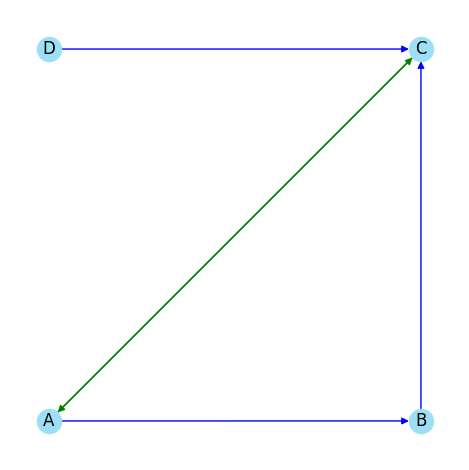

In [4]:
Graf1 = nx.DiGraph()
Graf1.add_nodes_from(range(4))
Graf1.add_edges_from([(0,1),(1,2),(3,2)], color="blue")
Graf1.add_edges_from([(0,2),(2,0)], color="green")
etiquetes1 = dict(zip(Graf1, string.ascii_uppercase)) # Construïm un diccionari per a les etiquetes
Graf1 = nx.relabel_nodes(Graf1, etiquetes1) # Reescrivim les etiquetes
dibuix(Graf1, -2.356194)

In [5]:
PR115 = PageRank(Graf1, 0.15)
PR15 = PageRank(Graf1, 0.5)
show(PR115)
show(PR15)

NameError: name 'matrix' is not defined

In [6]:
print("Per p = 0.15:")
ordre(PR115)
print("Per p = 0.5:")
ordre(PR15)

Per p = 0.15:


NameError: name 'PR115' is not defined

In [7]:
dibuix(Graf1, -2.356194, "p=0.15", PR115)
dibuix(Graf1, -2.356194, "p=0.5", PR15)

NameError: name 'PR115' is not defined

## Amb tot el graf de la Viquipèdia

### Explicació del funcionament del programa
Primer, per compilar getAllConnectionEntries.cpp (i també namesAndIds.cpp) s'ha de fer la comanda `g++ -std=c++17 -I/opt/homebrew/include ./getAllConnectionEntries.cpp -L/opt/homebrew/lib -lzim -o getAllConnectionEntries` i després executar-ho amb `./getAllConnectionEntries ./wikipedia_ca_all_nopic.zim` (ídem en el cas de namesAndIds.cpp). 

Els resultats obtinguts amb aquset programa ja son proporcionats (entriesConnections.txt i nameToID.txt) ja que per fer aixó d'adalt s'hauria de instalar la llibreria zim, que és la que llegeix els fitxers, descarregar el fitxer `wikipedia_ca_all_nopic.zim` i executar el programa (triga aproximadament 15 minuts). És per aixó que els resultats d'aquesta part son proporcionats. 

Després d'alló, només queda fer el PageRank, primer compilar amb `g++ -std=c++17 ./pageRanker.cpp -o pageRanker` i després amb `./pageRanker <factor>` genera un fitxer amb nom `damping<factor*100>.txt` a `resultatsPageRank` amb resultats ordenats de forma ascendent.

Notem com, en els que hem fet nosaltres quant més gran es el dumping factor més triga en convergir (per a un epsilon de 1e-8):

| d    | Iteracions necessàries|
|------|-----------------------|
| 0.5  | 18                    |
| 0.7  | 29                    |
| 0.85 | 52                    |
| 0.99 | 840                   |


### Analisi PageRank Complet

In [27]:
from os import listdir

nom_to_pos : dict[str:list[int]] = {i:[] for i in nameToId} 

for damp in sorted(listdir("allPageRank/resultatsPageRank")):
    print("\nAmb", float(damp[7:-4])/100, "com a factor d'esmorteïment:")
    i = 0
    with open("allPageRank/resultatsPageRank/" + damp) as f:
        for line in f.readlines():
            w_id, punt = line.split(": ")
            if int(w_id) in idToName:
                i += 1
                nom_to_pos[idToName[int(w_id)]].append(i)
                if i < 6:
                    print(f"\t {i}.- {idToName[int(w_id)]}: {punt[:-1]}")

nom_to_pos_invar : dict[str:int] = {}
nom_to_diferencia_pos : dict[str:int] = {}
for nom, posicions in nom_to_pos.items():
    if all(p == posicions[0] for p in posicions):
        nom_to_pos_invar[nom] = posicions[0]
    else:
        primer = posicions[0]
        ultim = posicions[-1]
        nom_to_diferencia_pos[nom] = primer-ultim

print("\nCiutats sense discusió de posició:")
for nom, pos in sorted(nom_to_pos_invar.items(), key=lambda i: i[1]):
    print("\t-",nom,"a", pos)

print("\nCiutats amb més diferencia de posicions:")
for nom, pos in sorted(nom_to_diferencia_pos.items(), key=lambda i: -abs(i[1]))[:5]:
    print("\t-",nom,"amb", pos, (nom_to_pos[nom][0], nom_to_pos[nom][-1]))



Amb 0.5 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000106482
	 2.- Terrassa: 7.54056e-05
	 3.- Sant Cugat del Vallès: 4.46182e-05
	 4.- Granollers: 3.42856e-05
	 5.- La Garriga: 2.13281e-05

Amb 0.7 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000146681
	 2.- Terrassa: 9.73816e-05
	 3.- Sant Cugat del Vallès: 5.42709e-05
	 4.- Granollers: 4.24501e-05
	 5.- La Garriga: 2.38732e-05

Amb 0.85 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000172196
	 2.- Terrassa: 0.000106695
	 3.- Sant Cugat del Vallès: 5.64928e-05
	 4.- Granollers: 4.44946e-05
	 5.- La Garriga: 2.24942e-05

Amb 0.99 com a factor d'esmorteïment:
	 1.- Sabadell: 0.000178901
	 2.- Terrassa: 0.000100249
	 3.- Sant Cugat del Vallès: 5.02498e-05
	 4.- Granollers: 3.86159e-05
	 5.- Cerdanyola del Vallès: 1.77947e-05

Ciutats sense discusió de posició:
	- Sabadell a 1
	- Terrassa a 2
	- Sant Cugat del Vallès a 3
	- Granollers a 4
	- L'Ametlla del Vallès a 19
	- Montmeló a 22

Ciutats amb més diferencia de posicions:
	- B

Podem veure que hi han diverses posicions que son indiscutibles, com la de Terrassa, Sababell, Sant Cugat del Vallès i Granollers a les 4 més importants.

També podem veure com altres amb dumping factor més baix es veuen afavorits ja que tenen moltes connexions (Bigues i Riells i Lliçà d'Amunt), mentre d'altres amb el factor més alt és veuen beneficiades (com Sant Quirze del Vallès o Badia del Vallès) degut a que tenen connexions amb nodes de major qualitat.